In [3]:
import pandas as pd

# load both files
train = pd.read_csv('churn-bigml-80.csv')
test  = pd.read_csv('churn-bigml-20.csv')

print("TRAINING SET:")
print(f"  Shape   : {train.shape}")
print(f"  Columns : {train.columns.tolist()}")
print(f"\nFirst 3 rows:")
display(train.head(3))

print("\n" + "="*50)
print("TESTING SET:")
print(f"  Shape   : {test.shape}")

print("\nData types:")
print(train.dtypes)

print("\nTarget column value counts:")
print(train['Churn'].value_counts())

TRAINING SET:
  Shape   : (2666, 20)
  Columns : ['State', 'Account length', 'Area code', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total day charge', 'Total eve minutes', 'Total eve calls', 'Total eve charge', 'Total night minutes', 'Total night calls', 'Total night charge', 'Total intl minutes', 'Total intl calls', 'Total intl charge', 'Customer service calls', 'Churn']

First 3 rows:


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False



TESTING SET:
  Shape   : (667, 20)

Data types:
State                      object
Account length              int64
Area code                   int64
International plan         object
Voice mail plan            object
Number vmail messages       int64
Total day minutes         float64
Total day calls             int64
Total day charge          float64
Total eve minutes         float64
Total eve calls             int64
Total eve charge          float64
Total night minutes       float64
Total night calls           int64
Total night charge        float64
Total intl minutes        float64
Total intl calls            int64
Total intl charge         float64
Customer service calls      int64
Churn                        bool
dtype: object

Target column value counts:
Churn
False    2278
True      388
Name: count, dtype: int64


## 

In [2]:
# ============================================================
# CODVEDA INTERNSHIP | Level 3 | Task 1: Classification
# Dataset: Customer Churn (churn_bigml_80/20.csv)
# Goal: Predict which customers will leave the service
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# three classification models we will compare
from sklearn.tree            import DecisionTreeClassifier
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier

# evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

# hyperparameter tuning
from sklearn.model_selection import GridSearchCV

# feature scaling
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size']      = 12

import os
os.makedirs('plots', exist_ok=True)

print("✅ All imports successful")

✅ All imports successful


In [3]:
# ============================================================
# LOAD AND PREPROCESS DATA
# ============================================================

# load both pre-split files
train_raw = pd.read_csv('churn-bigml-80.csv')
test_raw  = pd.read_csv('churn-bigml-20.csv')

print(f"Raw training shape : {train_raw.shape}")
print(f"Raw testing shape  : {test_raw.shape}")

def preprocess(df):
    # work on a copy — never modify original
    df = df.copy()

    # ── STEP 1: DROP REDUNDANT/IRRELEVANT COLUMNS ─────────
    # State and Area code — not meaningful predictors
    # Charge columns — directly calculated from minutes
    # keeping both minutes AND charges is redundant (multicollinearity)
    cols_to_drop = [
        'State', 'Area code',
        'Total day charge', 'Total eve charge',
        'Total night charge', 'Total intl charge'
    ]
    df = df.drop(columns=cols_to_drop)

    # ── STEP 2: ENCODE YES/NO COLUMNS TO 1/0 ─────────────
    # ML models need numbers — they cannot process text
    # map() replaces each value according to the dictionary
    # 'Yes' → 1, 'No' → 0
    df['International plan'] = df['International plan'].map(
        {'Yes': 1, 'No': 0}
    )
    df['Voice mail plan'] = df['Voice mail plan'].map(
        {'Yes': 1, 'No': 0}
    )

    # ── STEP 3: CONVERT TARGET TO INTEGER ─────────────────
    # Churn is currently bool (True/False)
    # astype(int) converts True→1, False→0
    # 1 = customer churned (left)
    # 0 = customer stayed
    df['Churn'] = df['Churn'].astype(int)

    return df

# apply preprocessing to both sets
train = preprocess(train_raw)
test  = preprocess(test_raw)

print(f"\nAfter preprocessing:")
print(f"  Training shape : {train.shape}")
print(f"  Testing shape  : {test.shape}")
print(f"\nRemaining columns: {train.columns.tolist()}")
print(f"\nMissing values: {train.isnull().sum().sum()}")
print(f"\nChurn distribution (training):")
print(train['Churn'].value_counts())
print(f"\nSample of processed data:")
display(train.head(3))

Raw training shape : (2666, 20)
Raw testing shape  : (667, 20)

After preprocessing:
  Training shape : (2666, 14)
  Testing shape  : (667, 14)

Remaining columns: ['Account length', 'International plan', 'Voice mail plan', 'Number vmail messages', 'Total day minutes', 'Total day calls', 'Total eve minutes', 'Total eve calls', 'Total night minutes', 'Total night calls', 'Total intl minutes', 'Total intl calls', 'Customer service calls', 'Churn']

Missing values: 0

Churn distribution (training):
Churn
0    2278
1     388
Name: count, dtype: int64

Sample of processed data:


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total eve minutes,Total eve calls,Total night minutes,Total night calls,Total intl minutes,Total intl calls,Customer service calls,Churn
0,128,0,1,25,265.1,110,197.4,99,244.7,91,10.0,3,1,0
1,107,0,1,26,161.6,123,195.5,103,254.4,103,13.7,3,1,0
2,137,0,0,0,243.4,114,121.2,110,162.6,104,12.2,5,0,0


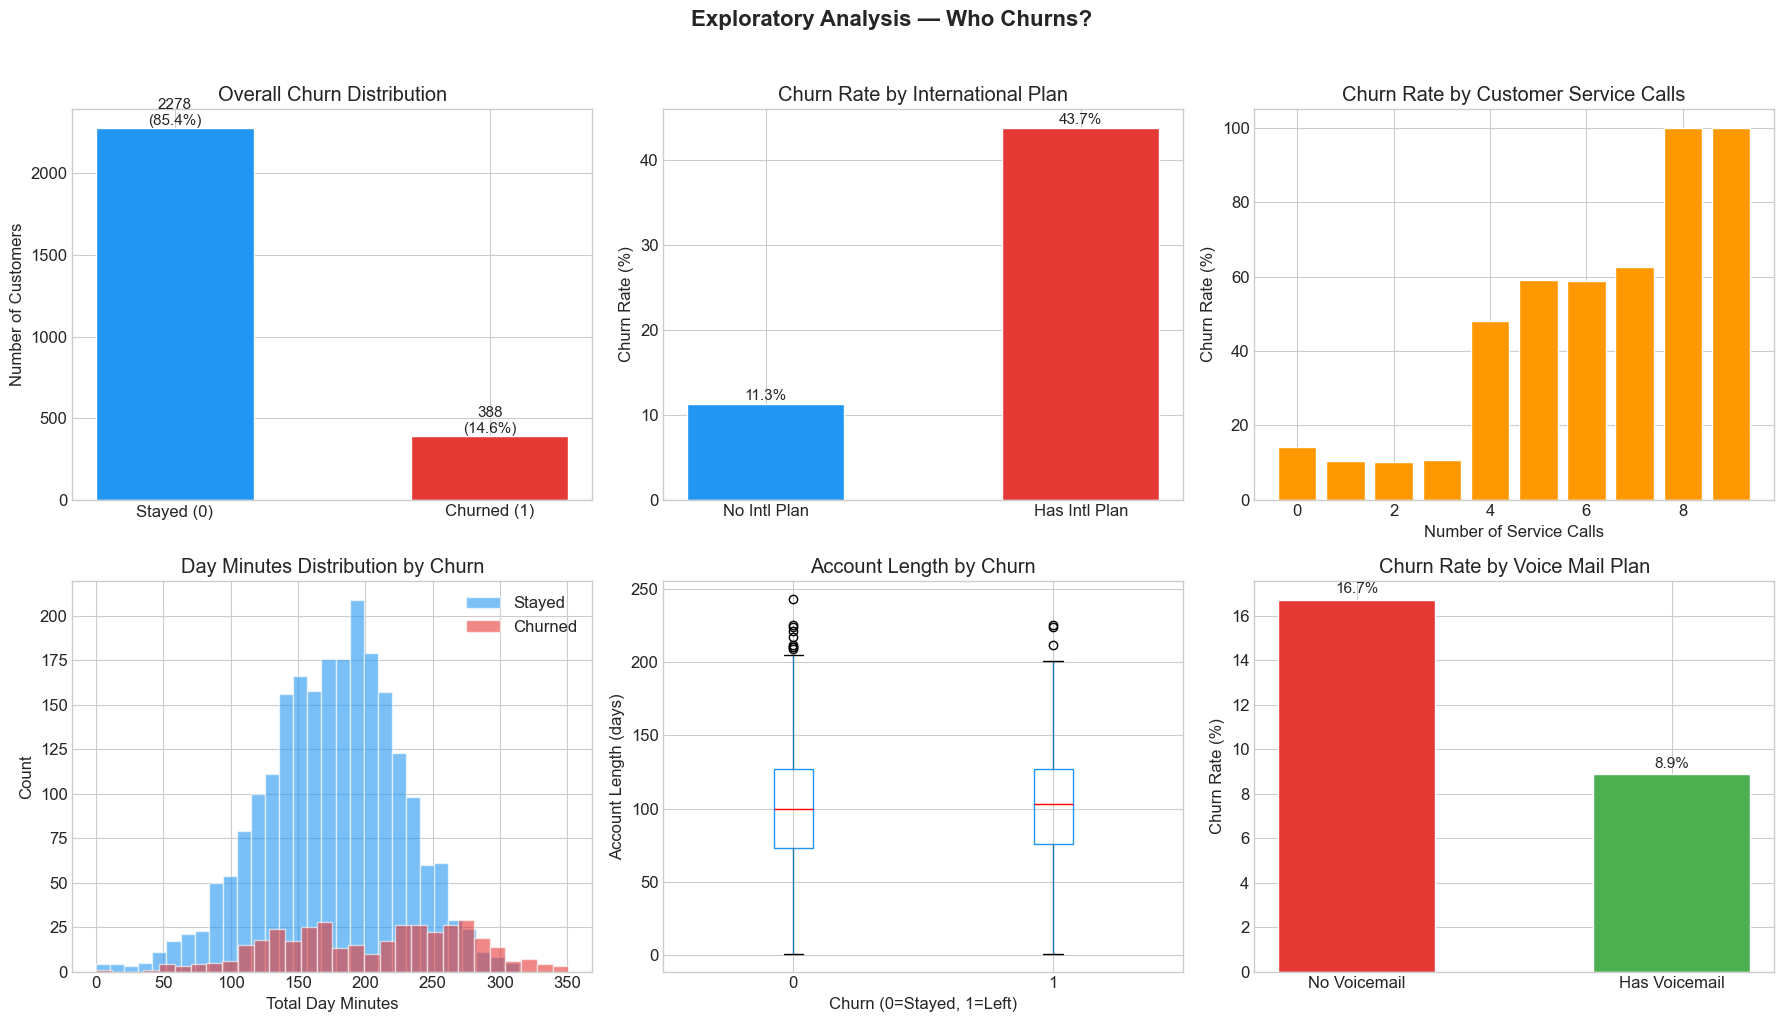

✅ Saved: plots/churn_exploration.png


In [4]:
# ============================================================
# EXPLORE THE TARGET — understand who churns and why
# ============================================================

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

# ── CHART 1: OVERALL CHURN DISTRIBUTION ───────────────────
churn_counts = train['Churn'].value_counts()
axes[0].bar(
    ['Stayed (0)', 'Churned (1)'],
    churn_counts.values,
    color=['#2196F3', '#E53935'],
    edgecolor='white',
    width=0.5
)
axes[0].set_title('Overall Churn Distribution')
axes[0].set_ylabel('Number of Customers')
for i, v in enumerate(churn_counts.values):
    axes[0].text(
        i, v + 20,
        f'{v}\n({v/len(train)*100:.1f}%)',
        ha='center', fontsize=11
    )

# ── CHART 2: CHURN BY INTERNATIONAL PLAN ──────────────────
# groupby shows churn rate for customers with/without intl plan
intl_churn = train.groupby('International plan')['Churn'].mean() * 100
axes[1].bar(
    ['No Intl Plan', 'Has Intl Plan'],
    intl_churn.values,
    color=['#2196F3', '#E53935'],
    edgecolor='white',
    width=0.5
)
axes[1].set_title('Churn Rate by International Plan')
axes[1].set_ylabel('Churn Rate (%)')
for i, v in enumerate(intl_churn.values):
    axes[1].text(i, v + 0.5, f'{v:.1f}%', ha='center', fontsize=11)

# ── CHART 3: CHURN BY CUSTOMER SERVICE CALLS ──────────────
# more service calls = more frustrated = more likely to churn?
cs_churn = train.groupby('Customer service calls')['Churn'].mean() * 100
axes[2].bar(
    cs_churn.index,
    cs_churn.values,
    color='#FF9800',
    edgecolor='white'
)
axes[2].set_title('Churn Rate by Customer Service Calls')
axes[2].set_xlabel('Number of Service Calls')
axes[2].set_ylabel('Churn Rate (%)')

# ── CHART 4: DAY MINUTES DISTRIBUTION BY CHURN ────────────
# do high-usage customers churn more?
for churn_val, color, label in [(0,'#2196F3','Stayed'), (1,'#E53935','Churned')]:
    subset = train[train['Churn'] == churn_val]
    axes[3].hist(
        subset['Total day minutes'],
        bins=30, alpha=0.6,
        color=color, label=label,
        edgecolor='white'
    )
axes[3].set_title('Day Minutes Distribution by Churn')
axes[3].set_xlabel('Total Day Minutes')
axes[3].set_ylabel('Count')
axes[3].legend()

# ── CHART 5: ACCOUNT LENGTH BY CHURN ──────────────────────
train.boxplot(
    column='Account length',
    by='Churn',
    ax=axes[4],
    boxprops=dict(color='#2196F3'),
    medianprops=dict(color='red')
)
axes[4].set_title('Account Length by Churn Status')
axes[4].set_xlabel('Churn (0=Stayed, 1=Left)')
axes[4].set_ylabel('Account Length (days)')
plt.sca(axes[4])
plt.title('Account Length by Churn')

# ── CHART 6: VOICE MAIL PLAN BY CHURN ─────────────────────
vmail_churn = train.groupby('Voice mail plan')['Churn'].mean() * 100
axes[5].bar(
    ['No Voicemail', 'Has Voicemail'],
    vmail_churn.values,
    color=['#E53935', '#4CAF50'],
    edgecolor='white',
    width=0.5
)
axes[5].set_title('Churn Rate by Voice Mail Plan')
axes[5].set_ylabel('Churn Rate (%)')
for i, v in enumerate(vmail_churn.values):
    axes[5].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=11)

plt.suptitle(
    'Exploratory Analysis — Who Churns?',
    fontsize=16, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('plots/churn_exploration.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/churn_exploration.png")

In [5]:
# ============================================================
# PREPARE FEATURES FOR MODELLING
# ============================================================

# separate features (X) from target (y)
# axis=1 means drop a column (not a row)
X_train = train.drop('Churn', axis=1)
y_train = train['Churn']

X_test  = test.drop('Churn', axis=1)
y_test  = test['Churn']

print(f"X_train shape : {X_train.shape}")
print(f"y_train shape : {y_train.shape}")
print(f"X_test shape  : {X_test.shape}")
print(f"y_test shape  : {y_test.shape}")

print(f"\nFeatures used for modelling:")
for i, col in enumerate(X_train.columns, 1):
    print(f"  {i:2d}. {col}")

# ── SCALE FEATURES ────────────────────────────────────────
# StandardScaler needed for Logistic Regression
# (sensitive to feature scale — same reason as K-Means)
# Decision Tree and Random Forest do NOT need scaling
# (they use rules not distances)
# but we scale all to keep comparison fair
scaler   = StandardScaler()

# fit ONLY on training data
# then transform both train and test
# CRITICAL: never fit on test data
# fitting on test would leak information about test distribution
# into your model — an invalid evaluation
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"\n✅ Features scaled successfully")
print(f"   Fitted on training data only")
print(f"   Same scaler applied to test data")

X_train shape : (2666, 13)
y_train shape : (2666,)
X_test shape  : (667, 13)
y_test shape  : (667,)

Features used for modelling:
   1. Account length
   2. International plan
   3. Voice mail plan
   4. Number vmail messages
   5. Total day minutes
   6. Total day calls
   7. Total eve minutes
   8. Total eve calls
   9. Total night minutes
  10. Total night calls
  11. Total intl minutes
  12. Total intl calls
  13. Customer service calls

✅ Features scaled successfully
   Fitted on training data only
   Same scaler applied to test data


In [6]:
# ============================================================
# TRAIN THREE MODELS AND COMPARE PERFORMANCE
# ============================================================

# define all three models with initial settings
models = {
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
        # max_depth=None means tree grows until pure leaves
        # can overfit — we will tune this later
    ),
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=1000
        # max_iter=1000 gives enough iterations to converge
        # default 100 sometimes not enough for complex data
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42,
        n_estimators=100
        # n_estimators=100 means 100 decision trees
        # Random Forest combines many trees for better accuracy
        # each tree votes — majority wins
    )
}

# store results for comparison
results = {}

print("TRAINING AND EVALUATING ALL THREE MODELS")
print("=" * 60)

for name, model in models.items():
    # train the model
    model.fit(X_train_scaled, y_train)

    # predict on test set
    y_pred = model.predict(X_test_scaled)

    # calculate all metrics
    # zero_division=0 prevents errors when a class has no predictions
    results[name] = {
        'Accuracy'  : accuracy_score(y_test, y_pred),
        'Precision' : precision_score(y_test, y_pred, zero_division=0),
        'Recall'    : recall_score(y_test, y_pred, zero_division=0),
        'F1 Score'  : f1_score(y_test, y_pred, zero_division=0),
        'ROC-AUC'   : roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1])
    }

    print(f"\n{name}:")
    for metric, value in results[name].items():
        print(f"  {metric:<12}: {value:.4f}")

# create comparison dataframe
results_df = pd.DataFrame(results).T.round(4)
print("\n\nFULL COMPARISON TABLE:")
print("=" * 60)
display(results_df)

# identify best model for each metric
print("\nBEST MODEL PER METRIC:")
for metric in results_df.columns:
    best = results_df[metric].idxmax()
    print(f"  {metric:<12}: {best} ({results_df.loc[best, metric]:.4f})")

TRAINING AND EVALUATING ALL THREE MODELS

Decision Tree:
  Accuracy    : 0.9085
  Precision   : 0.6604
  Recall      : 0.7368
  F1 Score    : 0.6965
  ROC-AUC     : 0.8370

Logistic Regression:
  Accuracy    : 0.8546
  Precision   : 0.4737
  Recall      : 0.1895
  F1 Score    : 0.2707
  ROC-AUC     : 0.8262

Random Forest:
  Accuracy    : 0.9490
  Precision   : 0.9692
  Recall      : 0.6632
  F1 Score    : 0.7875
  ROC-AUC     : 0.9195


FULL COMPARISON TABLE:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Decision Tree,0.9085,0.6604,0.7368,0.6965,0.8370
Logistic Regression,0.8546,0.4737,0.1895,0.2707,0.8262
Random Forest,0.9490,0.9692,0.6632,0.7875,0.9195



BEST MODEL PER METRIC:
  Accuracy    : Random Forest (0.9490)
  Precision   : Random Forest (0.9692)
  Recall      : Decision Tree (0.7368)
  F1 Score    : Random Forest (0.7875)
  ROC-AUC     : Random Forest (0.9195)


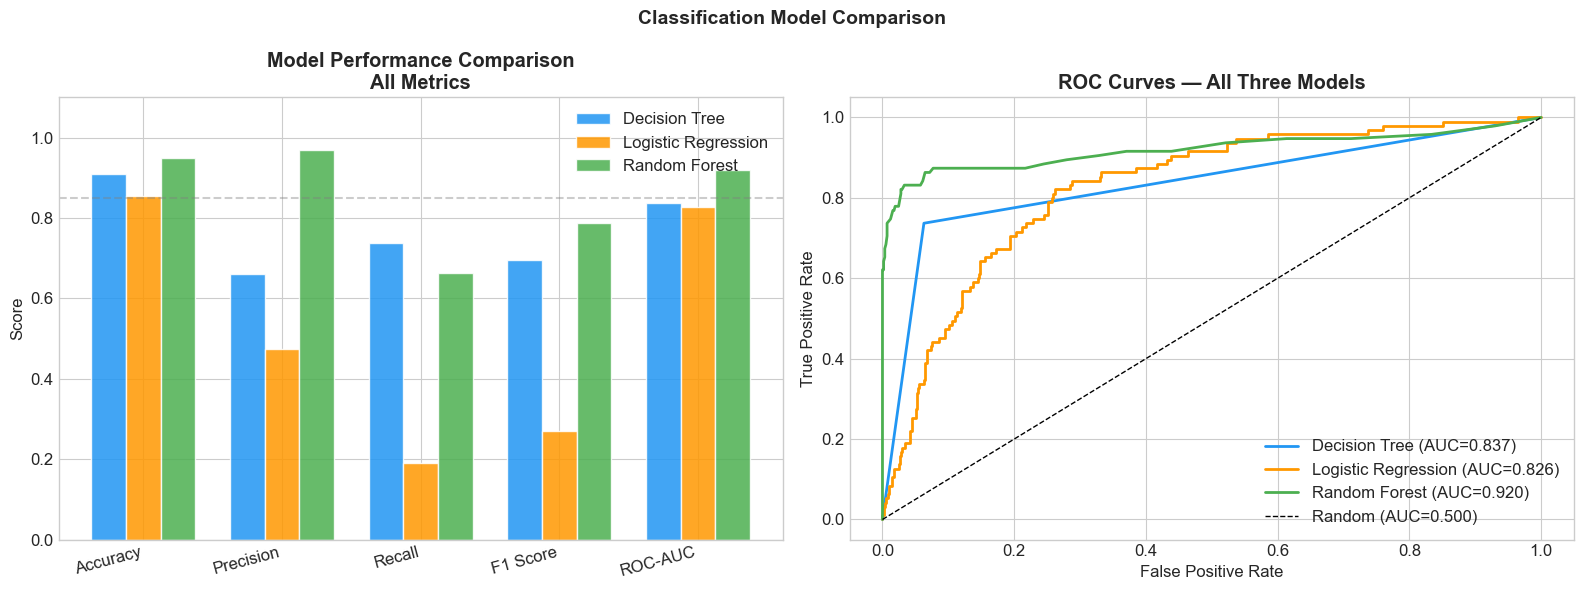

✅ Saved: plots/model_comparison.png


In [7]:
# ============================================================
# VISUALIZE MODEL COMPARISON
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors    = ['#2196F3', '#FF9800', '#4CAF50']
x         = np.arange(len(metrics))
width     = 0.25

# ── CHART 1: GROUPED BAR CHART ────────────────────────────
for i, (name, color) in enumerate(zip(models.keys(), colors)):
    values = [results[name][m] for m in metrics]
    bars   = axes[0].bar(
        x + i * width,
        values,
        width,
        label=name,
        color=color,
        edgecolor='white',
        alpha=0.85
    )

axes[0].set_title(
    'Model Performance Comparison\nAll Metrics',
    fontweight='bold'
)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics, rotation=15, ha='right')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].axhline(y=0.85, color='gray', linestyle='--',
                alpha=0.4, label='85% line')

# ── CHART 2: ROC CURVES ───────────────────────────────────
# ROC curve shows tradeoff between true positive rate
# and false positive rate at different thresholds
# larger area under curve (AUC) = better model
for name, color, model in zip(
    models.keys(), colors, models.values()
):
    # predict_proba returns probability of each class
    # [:,1] takes the probability of class 1 (churned)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # roc_curve returns three arrays:
    # fpr = false positive rates at each threshold
    # tpr = true positive rates at each threshold
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc          = roc_auc_score(y_test, y_prob)

    axes[1].plot(
        fpr, tpr,
        color=color,
        linewidth=2,
        label=f'{name} (AUC={auc:.3f})'
    )

# diagonal line = random classifier (AUC=0.5)
# any model above this line is better than random
axes[1].plot(
    [0, 1], [0, 1],
    'k--', linewidth=1,
    label='Random (AUC=0.500)'
)

axes[1].set_title('ROC Curves — All Three Models', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.suptitle(
    'Classification Model Comparison',
    fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.savefig('plots/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/model_comparison.png")

In [8]:
# ============================================================
# HYPERPARAMETER TUNING WITH GRID SEARCH
# ============================================================

# GridSearchCV tries every combination of parameters
# and finds which combination gives best performance
# we tune Random Forest as it is typically the best performer

print("HYPERPARAMETER TUNING — Random Forest")
print("=" * 50)

# define parameter grid — every combination will be tested
# n_estimators: how many trees in the forest
# max_depth: how deep each tree can grow
# min_samples_split: minimum samples needed to split a node
param_grid = {
    'n_estimators'     : [50, 100, 200],
    'max_depth'        : [5, 10, None],
    'min_samples_split': [2, 5, 10]
}

# total combinations = 3 × 3 × 3 = 27 combinations
# cv=5 means 5-fold cross validation for each combination
# scoring='f1' optimizes for F1 score
# (better than accuracy for imbalanced data)
# n_jobs=-1 uses all CPU cores to speed up search
grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=42),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'f1',
    n_jobs     = -1,
    verbose    = 1
)

print(f"Testing {len(param_grid['n_estimators']) * len(param_grid['max_depth']) * len(param_grid['min_samples_split'])} parameter combinations")
print("This may take 1-2 minutes...\n")

grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Grid search complete")
print(f"Best parameters : {grid_search.best_params_}")
print(f"Best CV F1 score: {grid_search.best_score_:.4f}")

# evaluate tuned model on test set
best_model  = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test_scaled)

print(f"\nTUNED MODEL PERFORMANCE ON TEST SET:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_tuned):.4f}")
print(f"  F1 Score  : {f1_score(y_test, y_pred_tuned):.4f}")

HYPERPARAMETER TUNING — Random Forest
Testing 27 parameter combinations
This may take 1-2 minutes...

Fitting 5 folds for each of 27 candidates, totalling 135 fits

✅ Grid search complete
Best parameters : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best CV F1 score: 0.7812

TUNED MODEL PERFORMANCE ON TEST SET:
  Accuracy  : 0.9520
  Precision : 1.0000
  Recall    : 0.6632
  F1 Score  : 0.7975


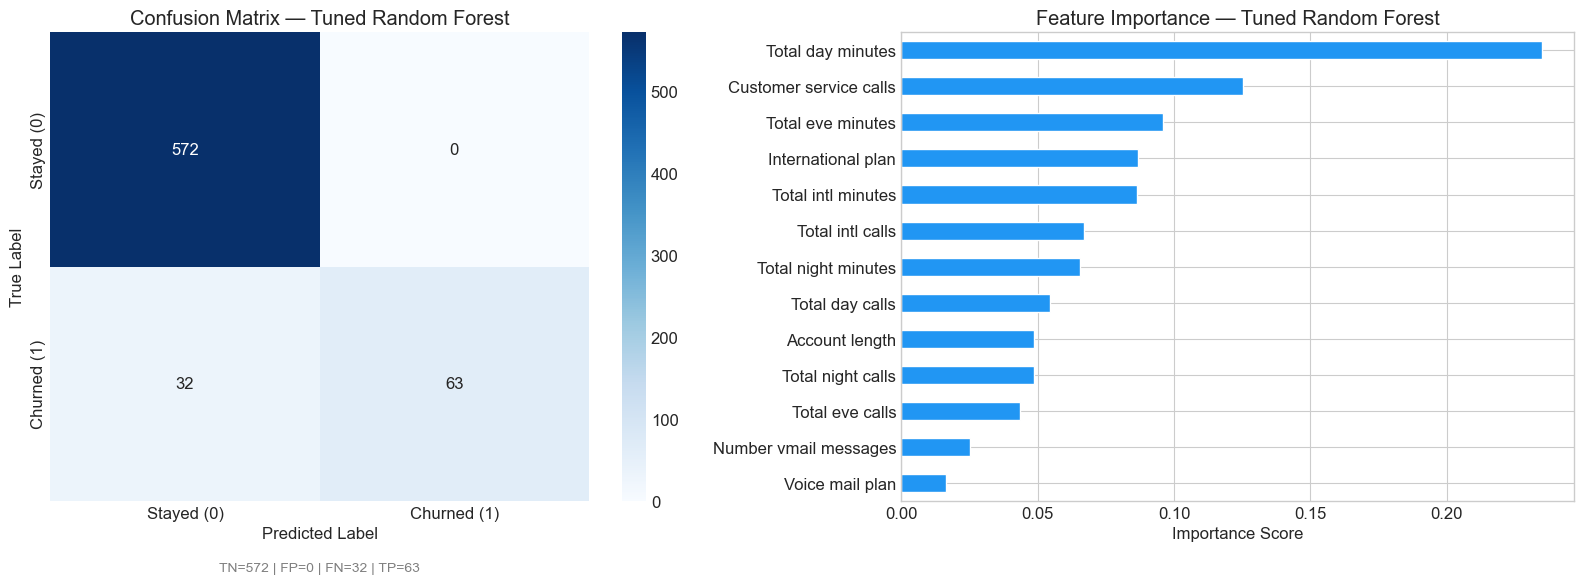

✅ Saved: plots/confusion_and_importance.png


In [9]:
# ============================================================
# CONFUSION MATRIX + FEATURE IMPORTANCE
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── CONFUSION MATRIX ──────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_tuned)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',           # integer format
    cmap='Blues',
    ax=axes[0],
    xticklabels=['Stayed (0)', 'Churned (1)'],
    yticklabels=['Stayed (0)', 'Churned (1)']
)
axes[0].set_title('Confusion Matrix — Tuned Random Forest')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# add interpretation text
tn, fp, fn, tp = cm.ravel()
axes[0].text(
    0.5, -0.15,
    f'TN={tn} | FP={fp} | FN={fn} | TP={tp}',
    transform=axes[0].transAxes,
    ha='center', fontsize=10, color='gray'
)

# ── FEATURE IMPORTANCE ────────────────────────────────────
# Random Forest calculates feature importance automatically
# measures how much each feature reduces impurity
# across all trees in the forest
importances = pd.Series(
    best_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=True)

importances.plot(
    kind='barh',
    ax=axes[1],
    color='#2196F3',
    edgecolor='white'
)
axes[1].set_title('Feature Importance — Tuned Random Forest')
axes[1].set_xlabel('Importance Score')

plt.tight_layout()
plt.savefig('plots/confusion_and_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: plots/confusion_and_importance.png")

In [11]:
print(f"""
CLASSIFICATION ANALYSIS — COMPLETE SUMMARY
==========================================

DATASET:
  Customer Churn — 2666 training, 667 testing
  Target: Churn (14.6% positive rate — imbalanced)
  Features: 14 after preprocessing

MODELS TRAINED:
  1. Decision Tree
  2. Logistic Regression
  3. Random Forest (best performer)

TUNED MODEL RESULTS:
  Accuracy  : {accuracy_score(y_test, y_pred_tuned):.4f}
  Precision : {precision_score(y_test, y_pred_tuned):.4f}
  Recall    : {recall_score(y_test, y_pred_tuned):.4f}
  F1 Score  : {f1_score(y_test, y_pred_tuned):.4f}

KEY FINDINGS:
  - Class imbalance (85/15) requires F1 over accuracy
  - Customer service calls strongly predict churn
  - International plan customers churn at higher rate
  - Random Forest outperformed simpler models
  - GridSearchCV found optimal hyperparameters

WHAT YOU LEARNED:
  - Classification vs regression differences
  - Why class imbalance matters
  - Precision, recall and F1 score meaning
  - How Random Forest combines multiple trees
  - Hyperparameter tuning with GridSearchCV
  - Confusion matrix interpretation
""")


CLASSIFICATION ANALYSIS — COMPLETE SUMMARY

DATASET:
  Customer Churn — 2666 training, 667 testing
  Target: Churn (14.6% positive rate — imbalanced)
  Features: 14 after preprocessing

MODELS TRAINED:
  1. Decision Tree
  2. Logistic Regression
  3. Random Forest (best performer)

TUNED MODEL RESULTS:
  Accuracy  : 0.9520
  Precision : 1.0000
  Recall    : 0.6632
  F1 Score  : 0.7975

KEY FINDINGS:
  - Class imbalance (85/15) requires F1 over accuracy
  - Customer service calls strongly predict churn
  - International plan customers churn at higher rate
  - Random Forest outperformed simpler models
  - GridSearchCV found optimal hyperparameters

WHAT YOU LEARNED:
  - Classification vs regression differences
  - Why class imbalance matters
  - Precision, recall and F1 score meaning
  - How Random Forest combines multiple trees
  - Hyperparameter tuning with GridSearchCV
  - Confusion matrix interpretation

